#Date Normalizer

## Opis problemu
Celem projektu jest budowa modelu sztucznej inteligencji typu **Transformer**, który potrafi tłumaczyć różne (często "bałaganiarskie") formaty zapisu dat wprowadzane przez człowieka na jeden standardowy format maszynowy ISO 8601 (`YYYY-MM-DD`).
Zadanie to realizowane jest jako problem translacji sekwencji na sekwencję (Sequence-to-Sequence).

## Przyjęta architektura rozwiązania
Model został zaimplementowany od podstaw w bibliotece PyTorch. Posiada on pełną architekturę typu **Encoder-Decoder**.
* Działamy na poziomie pojedynczych znaków (**Char-level Tokenizer**), co pozwala na drastyczne zmniejszenie rozmiaru słownika (vocab_size).
* Zarówno Encoder jak i Decoder wykorzystują mechanizm **Multi-Head Attention** (własnoręcznie zaimplementowane warstwy z jawnym podziałem na Query, Key, Value), co uniezależnia nas od "czarnych skrzynek" z gotowych bibliotek.

---
## Krok 1: Generowanie dataset'u.
Ponieważ model musi uczyć się na przykładach, przygotowaliśmy generator, który tworzy plik tekstowy zawierający 20 000 par dat o różnej strukturze (5 różnych struktur).

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt
import seaborn as sns

random.seed(42)
torch.manual_seed(42)

MONTHS = ["stycznia", "lutego", "marca", "kwietnia", "maja", "czerwca",
          "lipca", "sierpnia", "września", "października", "listopada", "grudnia"]

def days_in_month(m, y):
    if m in [4, 6, 9, 11]:
        return 30
    elif m == 2:
        return 29 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 28
    else:
        return 31

def generate_date():
    m = random.randint(1, 12)
    y = random.randint(2000, 2030)
    d = random.randint(1, days_in_month(m, y))

    format_choice = random.choice([1, 2, 3, 4, 5])

    if format_choice == 1:
        input_date = f"{d} {MONTHS[m-1]} {y}"
    elif format_choice == 2:
        input_date = f"{d:02d}.{m:02d}.{y}"
    elif format_choice == 3:
        input_date = f"{d:02d}/{m:02d}/{y}"
    elif format_choice == 4:
        input_date = f"{d}.{m}.{y}"
    else:
        input_date = f"{d}/{m}/{y}"

    target_date = f"{y}-{m:02d}-{d:02d}"

    return input_date, target_date

num_samples = 20000
print("Generowanie datasetu (obsługa różnych formatów wejściowych)...")

with open("date_dataset.txt", "w", encoding="utf-8") as f:
    for _ in range(num_samples):
        input_date, target_date = generate_date()
        f.write(f"{input_date}\t{target_date}\n")

print("Zapisano plik date_dataset.txt.")

Generowanie datasetu (obsługa różnych formatów wejściowych)...
Zapisano plik date_dataset.txt.


---
## Krok 2: Tokenizacja na poziomie znaków (Char-level Tokenizer)
Komputer operuje na liczbach, nie na literach. Ta klasa buduje słownik wszystkich unikalnych znaków występujących w datach i przypisuje im identyfikatory (ID). Dodajemy również tokeny specjalne: `<START>`, `<END>` oraz `<PAD>`.

In [ ]:
class DateTokenizer:
    def __init__(self):
        self.pad_token = "<PAD>"    # ID: 0
        self.start_token = "<START>" # ID: 1
        self.end_token = "<END>"     # ID: 2

        self.vocab = [self.pad_token, self.start_token, self.end_token]
        self.char2idx = {}
        self.idx2char = {}

    def build_vocab_from_file(self, file_path):
        chars = set()
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip().lower()
                for char in line:
                    if char != '\t':
                        chars.add(char)

        self.vocab.extend(sorted(list(chars)))
        self.char2idx = {char: i for i, char in enumerate(self.vocab)}
        self.idx2char = {i: char for i, char in enumerate(self.vocab)}

        print(f"Słownik zbudowany! Rozmiar słownika (vocab_size): {len(self.vocab)}")

    def encode(self, text, max_len, add_special_tokens=False):
        text = text.strip().lower()
        token_ids = [self.char2idx[char] for char in text if char in self.char2idx]

        if add_special_tokens:
            token_ids = [self.char2idx[self.start_token]] + token_ids + [self.char2idx[self.end_token]]

        if len(token_ids) < max_len:
            token_ids = token_ids + [self.char2idx[self.pad_token]] * (max_len - len(token_ids))
        else:
            token_ids = token_ids[:max_len]

        return torch.tensor(token_ids)

    def decode(self, token_ids):
        chars = []
        for token_id in token_ids:
            char = self.idx2char[token_id.item()]
            if char in [self.pad_token, self.start_token]:
                continue
            if char == self.end_token:
                break
            chars.append(char)
        return "".join(chars)

# Inicjalizacja
tokenizer = DateTokenizer()
tokenizer.build_vocab_from_file("date_dataset.txt")

Słownik zbudowany! Rozmiar słownika (vocab_size): 39


---
## Krok 3: Pakowanie w paczki (Dataset & DataLoader)
Przygotowujemy dane do treningu poprzez podział ich na tzw. *batche* (paczki). Każda sekwencja jest odpowiednio przycinana lub uzupełniana zerami (padding) do równej długości.

**Podział danych:** 90% danych trafia do zbioru treningowego (`train_loader`), a 10% do zbioru walidacyjnego (`val_loader`). Zbiór walidacyjny służy do monitorowania czy model się nie przeuczy - model nigdy nie widzi tych przykładów podczas treningu.

In [ ]:
class DateDataset(Dataset):
    def __init__(self, file_path, tokenizer, max_src_len=20, max_tgt_len=15):
        self.src_data = [] # Wejścia
        self.tgt_data = [] # Wyjścia

        print("Ładowanie i tokenizacja danych...")
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) == 2:
                    src_text, tgt_text = parts

                    src_tensor = tokenizer.encode(src_text, max_src_len, add_special_tokens=False)
                    tgt_tensor = tokenizer.encode(tgt_text, max_tgt_len, add_special_tokens=True)

                    self.src_data.append(src_tensor)
                    self.tgt_data.append(tgt_tensor)

        print(f"Załadowano {len(self.src_data)} przykładów!")

    def __len__(self):
        return len(self.src_data)

    def __getitem__(self, idx):
        return self.src_data[idx], self.tgt_data[idx]

# Wczytanie pełnego datasetu
full_dataset = DateDataset("date_dataset.txt", tokenizer)

# Podział 90% trening / 10% walidacja
total_size = len(full_dataset)
train_size = int(0.9 * total_size)
val_size = total_size - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)

print(f"Zbiór treningowy:   {train_size} przykładów")
print(f"Zbiór walidacyjny:  {val_size} przykładów")

# Test kształtów
sample_src, sample_tgt = next(iter(train_loader))
print(f"Kształt batcha źródłowego (src): {sample_src.shape}")
print(f"Kształt batcha docelowego (tgt): {sample_tgt.shape}")


Ładowanie i tokenizacja danych...
Załadowano 20000 przykładów!
Zbiór treningowy:   18000 przykładów
Zbiór walidacyjny:  2000 przykładów
Kształt batcha źródłowego (src): torch.Size([32, 20])
Kształt batcha docelowego (tgt): torch.Size([32, 15])


---
## Krok 4: Architektura Modelu (Transformer)
Serce naszego projektu. Wyraźnie widać tu trzy mechanizmy uwagi oraz warstwy normalizacji:
1. `encoder_attention` (Self-Attention) - Encoder "zrozumie" datę wejściową.
2. `decoder_self_attention` - Decoder patrzy na to, co już wygenerował (z maskowaniem przyszłości).
3. `decoder_cross_attention` - Decoder patrzy na notatki z Encodera, aby wygenerować kolejny znak.

Każda z tych sublayer jest otoczona schematem **Add & Norm** (residual connection + `LayerNorm`), zgodnie z architekturą opisaną w oryginalnej pracy *"Attention Is All You Need"* (Vaswani et al., 2017). Stabilizuje to trening i przyspiesza zbieżność.

Przepuszczam dane przez model...
Mapa atencji...


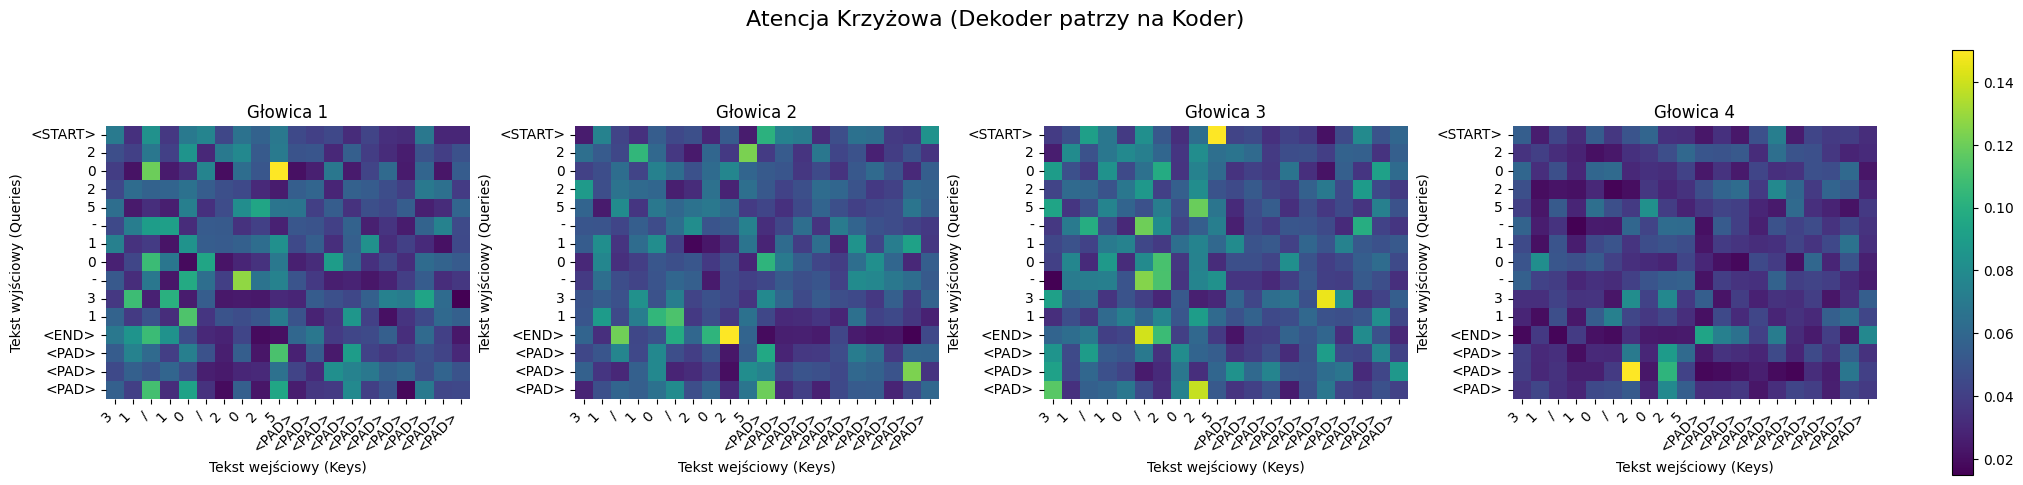

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        self.pos_embedding = nn.Embedding(max_len, d_model)

    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0)
        return x + self.pos_embedding(positions)

class DateTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4):
        super().__init__()
        self.d_model = d_model

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        # MHA (Multi-Head Attention)
        self.encoder_attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=True)
        self.decoder_self_attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=True)
        self.decoder_cross_attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=True)

        # FFN (Feed Forward Networks)
        self.encoder_ffn = nn.Sequential(nn.Linear(d_model, d_model*2), nn.ReLU(), nn.Linear(d_model*2, d_model))
        self.decoder_ffn = nn.Sequential(nn.Linear(d_model, d_model*2), nn.ReLU(), nn.Linear(d_model*2, d_model))

        # Layer Normalization (po każdej sublayer, zgodnie z oryginalnym Transformerem)
        self.encoder_norm1 = nn.LayerNorm(d_model)  # po self-attention encodera
        self.encoder_norm2 = nn.LayerNorm(d_model)  # po FFN encodera
        self.decoder_norm1 = nn.LayerNorm(d_model)  # po self-attention decodera
        self.decoder_norm2 = nn.LayerNorm(d_model)  # po cross-attention decodera
        self.decoder_norm3 = nn.LayerNorm(d_model)  # po FFN decodera

        self.fc_out = nn.Linear(d_model, vocab_size)

    def generate_square_subsequent_mask(self, sz, device):
        mask = torch.triu(torch.ones((sz, sz), device=device) * float('-inf'), diagonal=1)
        return mask

    def forward(self, src, tgt):
        # Embeddings + Positional Encoding
        src_emb = self.pos_encoder(self.embedding(src))
        tgt_emb = self.pos_encoder(self.embedding(tgt))

        # Encoder
        attn_out, encoder_attn_weights = self.encoder_attention(
            query=src_emb, key=src_emb, value=src_emb,
            average_attn_weights=False
        )
        encoder_output = self.encoder_norm1(src_emb + attn_out)
        encoder_output = self.encoder_norm2(encoder_output + self.encoder_ffn(encoder_output))

        # Decoder
        tgt_mask = self.generate_square_subsequent_mask(tgt_emb.size(1), tgt_emb.device)

        self_attn_out, dec_self_attn_weights = self.decoder_self_attention(
            query=tgt_emb, key=tgt_emb, value=tgt_emb, is_causal=True, attn_mask=tgt_mask,
            average_attn_weights=False
        )
        decoder_out1 = self.decoder_norm1(tgt_emb + self_attn_out)

        cross_attn_out, cross_attn_weights = self.decoder_cross_attention(
            query=decoder_out1, key=encoder_output, value=encoder_output,
            average_attn_weights=False
        )
        decoder_out2 = self.decoder_norm2(decoder_out1 + cross_attn_out)

        decoder_output = self.decoder_norm3(decoder_out2 + self.decoder_ffn(decoder_out2))

        logits = self.fc_out(decoder_output)

        return logits, {
            "encoder_self_attn": encoder_attn_weights,
            "decoder_self_attn": dec_self_attn_weights,
            "cross_attn": cross_attn_weights
        }

def plot_attention_heads(attention_weights, source_tokens, target_tokens, title="Mapa Atencji"):
    attn_matrix = attention_weights[0].detach().cpu().numpy()
    num_heads = attn_matrix.shape[0]

    fig, axes = plt.subplots(1, num_heads, figsize=(5 * num_heads, 5))
    if num_heads == 1:
        axes = [axes]

    fig.suptitle(title, fontsize=16)

    for i in range(num_heads):
        ax = axes[i]
        sns.heatmap(
            attn_matrix[i],
            xticklabels=source_tokens,
            yticklabels=target_tokens,
            cmap="viridis",
            cbar=False,
            ax=ax,
            square=True
        )
        ax.set_title(f'Głowica {i+1}')
        ax.set_xlabel('Tekst wejściowy (Keys)')
        ax.set_ylabel('Tekst wyjściowy (Queries)')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    plt.tight_layout()

    mappable = axes[0].collections[0]
    fig.colorbar(mappable, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.015, pad=0.04)

    plt.show()

vocab_size = len(tokenizer.vocab)
model = DateTransformer(vocab_size=vocab_size, d_model=64, num_heads=4)

print("Przepuszczam dane przez model...")

logits, attention_dicts = model(sample_src, sample_tgt)

src_chars = [tokenizer.idx2char[idx.item()] for idx in sample_src[0]]
tgt_chars = [tokenizer.idx2char[idx.item()] for idx in sample_tgt[0]]

print("Mapa atencji...")
plot_attention_heads(
    attention_weights=attention_dicts["cross_attn"],
    source_tokens=src_chars,
    target_tokens=tgt_chars,
    title="Atencja Krzyżowa (Dekoder patrzy na Koder)"
)

---
## Krok 5: Pętla Ucząca (Training Loop)
Proces optymalizacji wag modelu (nauka z nauczycielem) z wykorzystaniem optymalizatora Adam oraz funkcji straty CrossEntropyLoss.

Po każdej epoce model jest dodatkowo oceniany na **zbiorze walidacyjnym** (tryb `model.eval()`, bez obliczania gradientów). Porównanie `Training Loss` i `Validation Loss` pozwala wykryć przeuczenie:
- Jeśli obie straty maleją razem → model uczy się poprawnie
- Jeśli `val_loss` rośnie, a `train_loss` maleje → model się przeuczył

In [ ]:
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.char2idx[tokenizer.pad_token])
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

# Listy do zbierania strat — potrzebne do wykresu
train_losses = []
val_losses   = []

print("Rozpoczęcie trenowania modelu (Training Loop)...")

for epoch in range(epochs):

    # --- FAZA TRENINGOWA ---
    model.train()
    total_train_loss = 0
    for src_batch, tgt_batch in train_loader:
        optimizer.zero_grad()

        tgt_input    = tgt_batch[:, :-1]
        tgt_expected = tgt_batch[:, 1:]

        logits, _ = model(src_batch, tgt_input)

        # Flatten (Spłaszczanie do 2D dla funkcji kosztu PyTorcha)
        logits_flat  = logits.reshape(-1, logits.shape[-1])
        targets_flat = tgt_expected.reshape(-1)

        loss = criterion(logits_flat, targets_flat)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- FAZA WALIDACYJNA ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for src_batch, tgt_batch in val_loader:
            tgt_input    = tgt_batch[:, :-1]
            tgt_expected = tgt_batch[:, 1:]

            logits, _ = model(src_batch, tgt_input)

            logits_flat  = logits.reshape(-1, logits.shape[-1])
            targets_flat = tgt_expected.reshape(-1)

            loss = criterion(logits_flat, targets_flat)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

print("\nTrening zakończony!")


Rozpoczęcie trenowania modelu (Training Loop)...
Epoch 01/10 | Train Loss: 0.2496 | Val Loss: 0.0026
Epoch 02/10 | Train Loss: 0.0031 | Val Loss: 0.0035
Epoch 03/10 | Train Loss: 0.0009 | Val Loss: 0.0003
Epoch 04/10 | Train Loss: 0.0002 | Val Loss: 0.0001
Epoch 05/10 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 06/10 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 07/10 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 08/10 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 09/10 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 10/10 | Train Loss: 0.0000 | Val Loss: 0.0000

Trening zakończony!


---
## Krok 5b: Wykres przebiegu uczenia
Poniższy wykres przedstawia wartości funkcji straty na zbiorze treningowym i walidacyjnym w kolejnych epokach. Brak rozbieżności między obiema krzywymi potwierdza, że model **nie uległ przeuczeniu (overfitting)**.

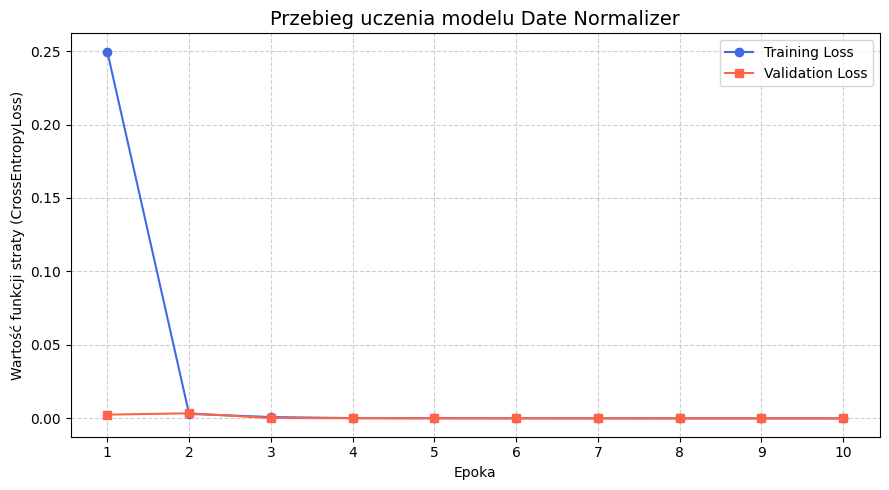

Końcowy Train Loss: 0.0000
Końcowy Val Loss:   0.0000
Wykres pokazuje stabilną zbieżność modelu. Training Loss i Validation Loss maleją równolegle, co potwierdza brak overfittingu.


In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs + 1), train_losses, marker='o', label='Training Loss',   color='royalblue')
plt.plot(range(1, epochs + 1), val_losses,   marker='s', label='Validation Loss', color='tomato')
plt.title('Przebieg uczenia modelu Date Normalizer', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Wartość funkcji straty (CrossEntropyLoss)')
plt.xticks(range(1, epochs + 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Końcowy Train Loss: {train_losses[-1]:.4f}")
print(f"Końcowy Val Loss:   {val_losses[-1]:.4f}")
if abs(train_losses[-1] - val_losses[-1]) < 0.05:
    print("Wykres pokazuje stabilną zbieżność modelu. Training Loss i Validation Loss maleją równolegle, co potwierdza brak overfittingu.")
else:
    print("Uwaga: Znaczna różnica między train a val loss - możliwe przeuczenie.")


---
## Krok 6: Testy na żywo (Inference)
Model wyłącza tryb nauki i w sposób autoregresyjny generuje wyniki znak po znaku.

In [ ]:
def translate_date(model, tokenizer, input_text, max_len=15):
    model.eval()
    src_tensor = tokenizer.encode(input_text, max_len=20, add_special_tokens=False).unsqueeze(0)

    generated_tokens = [tokenizer.char2idx[tokenizer.start_token]]

    for _ in range(max_len):
        tgt_tensor = torch.tensor(generated_tokens).unsqueeze(0)

        with torch.no_grad():
            logits, _ = model(src_tensor, tgt_tensor)

        next_token_id = logits[0, -1, :].argmax().item()
        generated_tokens.append(next_token_id)

        if next_token_id == tokenizer.char2idx[tokenizer.end_token]:
            break

    return tokenizer.decode(torch.tensor(generated_tokens))

print("--- TESTY WNIOSKOWANIA (INFERENCE) ---")
test_cases = ["15 marca 2026", "04.12.2020", "28 lutego 2005", "1/01/2030", "5.3.2025"]

for test_case in test_cases:
    prediction = translate_date(model, tokenizer, test_case)
    print(f"Wejście: '{test_case:<15}' ---> Wynik: '{prediction}'")

--- TESTY WNIOSKOWANIA (INFERENCE) ---
Wejście: '15 marca 2026  ' ---> Wynik: '2026-03-15'
Wejście: '04.12.2020     ' ---> Wynik: '2020-12-04'
Wejście: '28 lutego 2005 ' ---> Wynik: '2005-02-28'
Wejście: '1/01/2030      ' ---> Wynik: '2030-01-01'
Wejście: '5.3.2025       ' ---> Wynik: '2025-03-05'


---
## Krok 7: Ewaluacja - Metryka Jakości (Accuracy)
Poniżej obliczamy metrykę jakości (Dokładność - Accuracy). Model jest testowany na zupełnie nowych, niewidzianych wcześniej 100 przykładach. Sprawdzana jest perfekcyjna zgodność całego wygenerowanego ciągu znaków (Exact Match).

In [ ]:
def evaluate_model_accuracy(model, tokenizer, num_tests=100):
    print(f"\n--- EWALUACJA MODELU ({num_tests} losowych próbek) ---")
    correct_predictions = 0

    for _ in range(num_tests):
        test_src, expected_tgt = generate_date()
        prediction = translate_date(model, tokenizer, test_src)

        if prediction == expected_tgt:
            correct_predictions += 1

    accuracy = (correct_predictions / num_tests) * 100

    print(f"Poprawne predykcje: {correct_predictions}/{num_tests}")
    print(f"Accuracy (Dokładność): {accuracy:.2f}%\n")
    return accuracy

evaluate_model_accuracy(model, tokenizer, num_tests=100)


--- EWALUACJA MODELU (100 losowych próbek) ---
Poprawne predykcje: 100/100
Accuracy (Dokładność): 100.00%



100.0